In [12]:
import pandas as pd 
import numpy as np 

from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from sklearn.preprocessing import scale, StandardScaler
from sklearn.cluster import AgglomerativeClustering

### Cargar los datos

In [13]:
titanic = pd.read_csv("/Users/gabychuX/Documents/GitHub/portafolio-python/data/titanic.csv")

In [14]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
titanic.rename(columns = {col: col.lower().replace ( '/', "_") for col in titanic.columns.values}, inplace = True)
titanic.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Transformación de variables

In [16]:
# modificamos sex
#titanic['sex'] = titanic['sex'].replace({'male': 0, 'female': 1})
titanic['sex'] = titanic['sex'].mask(titanic['sex'] == 'male', 0)
titanic['sex'] = titanic['sex'].mask(titanic['sex'] == 'female', 1)

titanic['sex'] = titanic. sex.astype (int)

titanic.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


In [17]:
titanic.describe()

,passengerid,survived,pclass,sex,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.352413,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,0.477990,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,1.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200


In [18]:
dataset = titanic.drop(['name'], axis=1)
dataset.head()

,passengerid,survived,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,0,35.0,0,0,373450,8.0500,NaN,S


In [19]:
titanic.describe()

,passengerid,survived,pclass,sex,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.352413,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,0.477990,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,1.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
dataset = titanic.drop (['name'], axis=1)
dataset.head()

,passengerid,survived,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,0,35.0,0,0,373450,8.0500,NaN,S


### Solo unas variables parte 2

In [21]:
dataset = titanic [['pclass', 'age']]

In [22]:
dataset = dataset.fillna(dataset.mean(numeric_only=True))

print(dataset.isnull().sum())

pclass    0
age       0
dtype: int64


## Escalando los datos

### 2 formas diferentes de hacerlo

In [23]:
dataset_scaled = scale(dataset)
dataset_scaled[:4]

array([[ 0.82737724, -0.5924806 ],
       [-1.56610693,  0.63878901],
       [ 0.82737724, -0.2846632 ],
       [-1.56610693,  0.40792596]])

In [24]:
ss = StandardScaler()
dataset_scaled = ss.fit_transform(dataset)
dataset_scaled [:4]

array([[ 0.82737724, -0.5924806 ],
       [-1.56610693,  0.63878901],
       [ 0.82737724, -0.2846632 ],
       [-1.56610693,  0.40792596]])

In [25]:
dataset_scaled.shape

(891, 2)

## Hclust

### Single linkage
### La distancia en cero aseguara que se crea toto del arbol

In [26]:
ac = AgglomerativeClustering(n_clusters=None, linkage='single', distance_threshold =0)

In [27]:
m1 = ac.fit(dataset_scaled)

In [28]:
m1.labels_[:5]

array([890, 685, 761, 633, 546])

In [29]:
m1.n_clusters_

891

###  Graficar el dendograma

In [30]:
def plot_dendogram(model, **kwargs):
    # Create linkage matrix and then plot dendrogram

    # Create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len (model.labels_)
    for i, merge in enumerate (model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1 # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_matrix = np.column_stack ([model.children_, model.distances_,
                                       counts]).astype(float)
    # Plot the corresponding dendogram
    dendrogram(linkage_matrix, **kwargs)

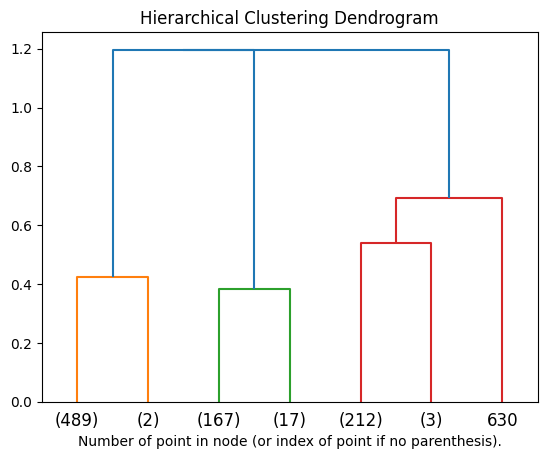

In [31]:
plt.title ('Hierarchical Clustering Dendrogram')
# plot the top three levels of the dendrogram
plot_dendogram(m1, truncate_mode = 'level', p=2)
plt.xlabel("Number of point in node (or index of point if no parenthesis).")
plt.show()